# Churn Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df=pd.read_csv('churn.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [9]:
df['Geography']=df['Geography'].astype('category')
df['Gender']=df['Gender'].astype('category')
df.dtypes

RowNumber             int64
CustomerId            int64
Surname              object
CreditScore           int64
Geography          category
Gender             category
Age                   int64
Tenure                int64
Balance             float64
NumOfProducts         int64
HasCrCard             int64
IsActiveMember        int64
EstimatedSalary     float64
Exited                int64
dtype: object

In [10]:
df.columns = df.columns.str.strip().str.lower()

In [11]:
df.head()

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# Total percentage churned

churn_rate = df['exited'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 20.37%


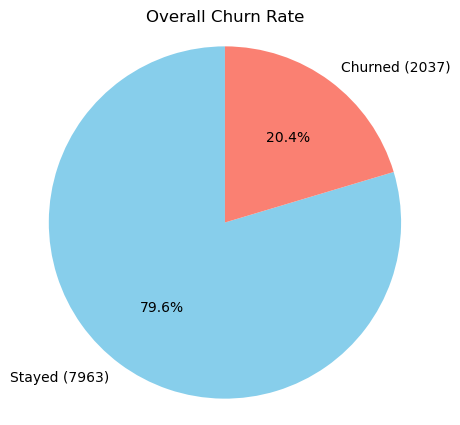

In [13]:
churn_counts = df['exited'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(churn_counts, labels=[f'Stayed ({churn_counts[0]})', f'Churned ({churn_counts[1]})'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Overall Churn Rate')
plt.axis('equal')
plt.show()

/var/folders/g6/0728tfpd6g7d0jrx72vxvtsw0000gn/T/ipykernel_70753/996105091.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  geography_churn = df.groupby('geography')['exited'].mean() * 100


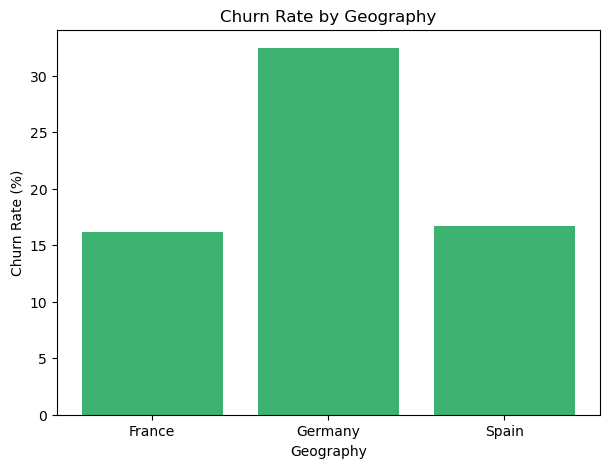

In [14]:
geography_churn = df.groupby('geography')['exited'].mean() * 100

plt.figure(figsize=(7,5))
plt.bar(geography_churn.index, geography_churn.values, color='mediumseagreen')
plt.title('Churn Rate by Geography')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Geography')
plt.show()

/var/folders/g6/0728tfpd6g7d0jrx72vxvtsw0000gn/T/ipykernel_70753/424377084.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='gender', y='exited', data=df, ci=None)


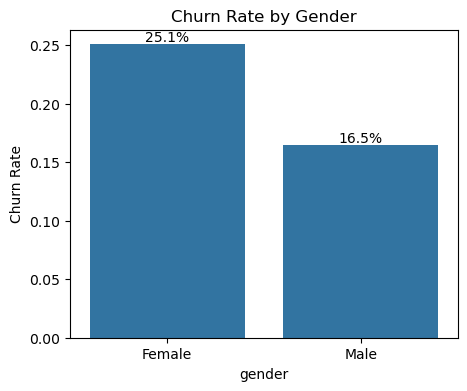

In [15]:
plt.figure(figsize=(5,4))
ax = sns.barplot(x='gender', y='exited', data=df, ci=None)
for p in ax.patches:
    value = p.get_height() * 100
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height(),
            f'{value:.1f}%',
            ha='center', va='bottom', fontsize=10)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

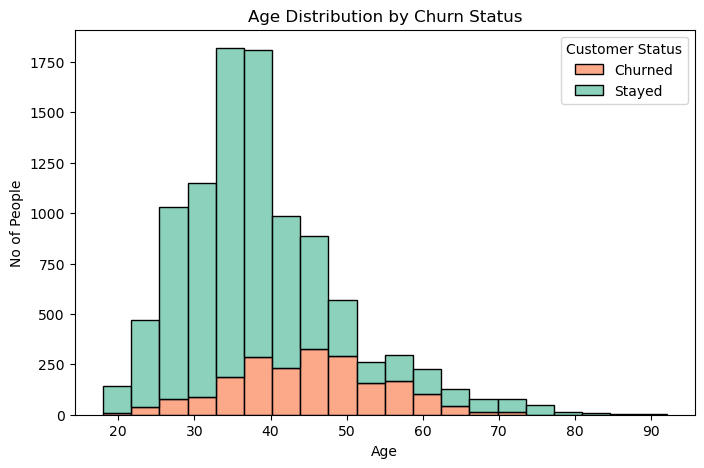

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age', hue='exited', multiple='stack', bins=20, palette='Set2')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('No of People')
plt.legend(title='Customer Status', labels=['Churned', 'Stayed'])
plt.show()

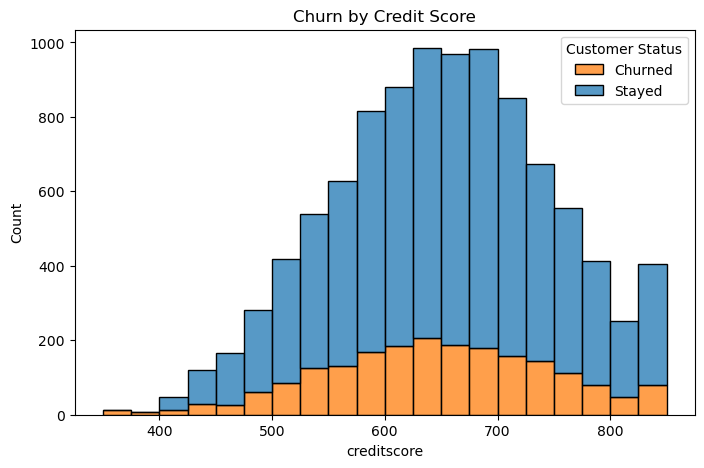

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='creditscore', hue='exited', multiple='stack', bins=20)
plt.title('Churn by Credit Score')
plt.legend(title='Customer Status', labels=['Churned', 'Stayed'])
plt.show()

/var/folders/g6/0728tfpd6g7d0jrx72vxvtsw0000gn/T/ipykernel_70753/3362013643.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='isactivemember', y='exited', data=df, color='yellow', ci=None)


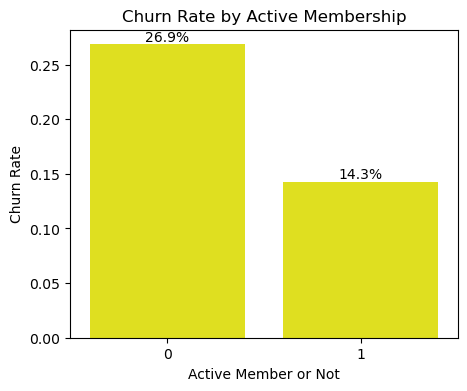

In [18]:
plt.figure(figsize=(5,4))
ax = sns.barplot(x='isactivemember', y='exited', data=df, color='yellow', ci=None)
for p in ax.patches:
    value = p.get_height() * 100
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height(),
            f'{value:.1f}%',
            ha='center', va='bottom', fontsize=10)
plt.title('Churn Rate by Active Membership')
plt.ylabel('Churn Rate')
plt.xlabel('Active Member or Not')
plt.show()

/var/folders/g6/0728tfpd6g7d0jrx72vxvtsw0000gn/T/ipykernel_70753/26431445.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='tenure', y='exited', data=df, ci=None, color='orange')


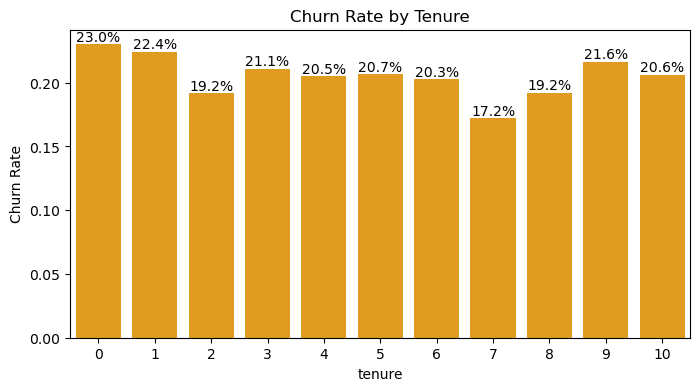

In [19]:
#Tenture

plt.figure(figsize=(8,4))
ax = sns.barplot(x='tenure', y='exited', data=df, ci=None, color='orange')
for p in ax.patches:
    value = p.get_height() * 100
    ax.text(p.get_x() + p.get_width()/2,
            p.get_height(),
            f'{value:.1f}%',
            ha='center', va='bottom', fontsize=10)
plt.title('Churn Rate by Tenure')
plt.ylabel('Churn Rate')
plt.show()

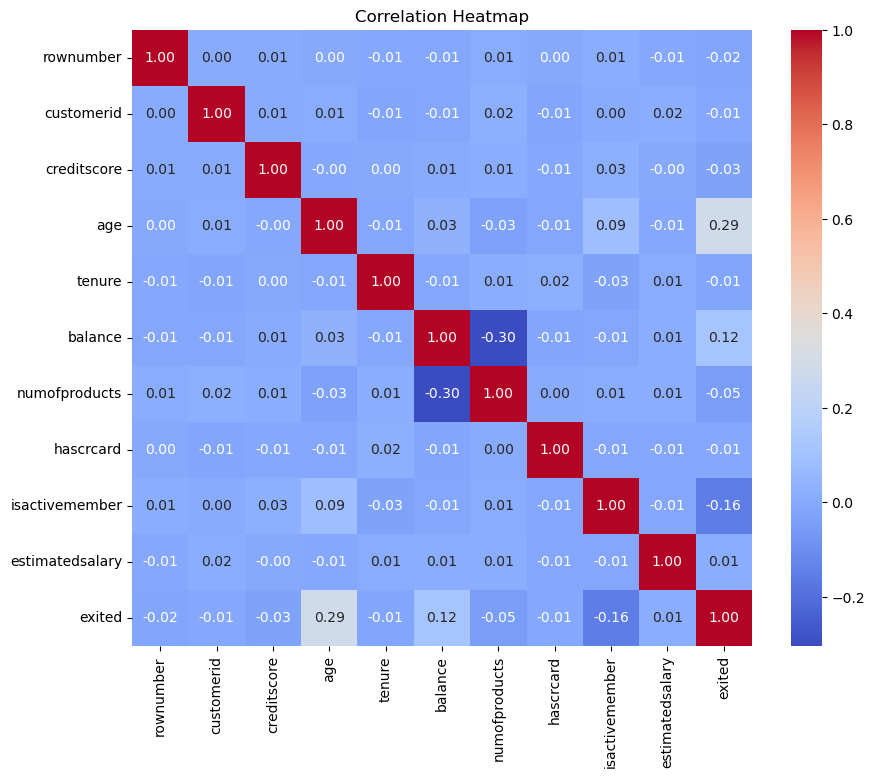

In [20]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

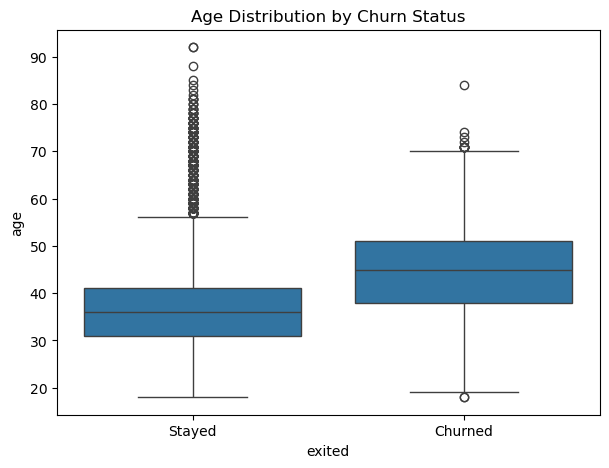

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='exited', y='age', data=df)
plt.title('Age Distribution by Churn Status')
plt.xticks([0, 1], ['Stayed', 'Churned'])
plt.show()

In [22]:
#Feature Engineering

In [23]:
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['18–25', '26–35', '36–45', '46–55', '56–65', '65+']
df['agegroup']=pd.cut(df['age'], bins=bins, labels=labels, right=True)
print(df['agegroup'].value_counts())

agegroup
36–45    3736
26–35    3542
46–55    1311
18–25     611
56–65     536
65+       264
Name: count, dtype: int64


In [24]:
def credit_risk_band(score):
    if score<580:
        return 'Poor'
    elif score<670:
        return 'Fair'
    elif score<740:
        return 'Good'
    elif score<800:
        return 'Very Good'
    else:
        return 'Excellent'

df['creditband'] = df['creditscore'].apply(credit_risk_band)
print(df['creditband'].value_counts())

creditband
Fair         3331
Good         2428
Poor         2362
Very Good    1224
Excellent     655
Name: count, dtype: int64


In [25]:
df['customervalue'] = df['balance'] * df['tenure']
df['valuesegment'] = pd.cut(df['customervalue'], bins=3, labels=['Low', 'Medium', 'High'])
#df[['balance', 'tenure', 'customervalue', 'valuesegment']].head()
print(df['valuesegment'].value_counts())

valuesegment
Low       7395
Medium    2371
High       234
Name: count, dtype: int64


In [26]:
df['balancecategory'] = pd.cut(df['balance'], bins=3, labels=['Low', 'Medium', 'High'])
print(df['balancecategory'].value_counts())

balancecategory
Medium    5262
Low       4353
High       385
Name: count, dtype: int64


In [49]:
bins = [0, 3, 7, 10]
labels = ['New', 'Mid', 'Loyal']
df['tenurebucket'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=True)
print(df['tenurebucket'].value_counts())

tenurebucket
Mid      3996
New      3092
Loyal    2499
Name: count, dtype: int64


In [28]:
bins = [0, 50000, 100000, 150000, 250000]
labels = ['Low', 'Medium', 'High', 'Very High']
df['salaryband'] = pd.cut(df['estimatedsalary'], bins=bins, labels=labels)
print(df['salaryband'].value_counts())

salaryband
High         2555
Medium       2537
Very High    2455
Low          2453
Name: count, dtype: int64


In [36]:
df['productsegment'] = df['numofproducts'].map({
    1: 'Single',
    2: 'Double',
    3: 'Triple',
    4: 'Four'
})
print(df['productsegment'].value_counts())

productsegment
Single    5084
Double    4590
Triple     266
Four        60
Name: count, dtype: int64


In [37]:
df[['agegroup', 'creditband', 'valuesegment', 'balancecategory', 'tenurebucket', 'salaryband', 'productsegment']].head()

,agegroup,creditband,valuesegment,balancecategory,tenurebucket,salaryband,productsegment
0,36–45,Fair,Low,Low,New,High,Single
1,36–45,Fair,Low,Medium,New,High,Single
2,36–45,Poor,Medium,Medium,Loyal,High,Triple
3,36–45,Good,Low,Low,New,Medium,Double
4,36–45,Excellent,Low,Medium,New,Medium,Single


In [38]:
print(df['agegroup'].value_counts(normalize=True))

agegroup
36–45    0.3736
26–35    0.3542
46–55    0.1311
18–25    0.0611
56–65    0.0536
65+      0.0264
Name: proportion, dtype: float64


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   rownumber        10000 non-null  int64   
 1   customerid       10000 non-null  int64   
 2   surname          10000 non-null  object  
 3   creditscore      10000 non-null  int64   
 4   geography        10000 non-null  category
 5   gender           10000 non-null  category
 6   age              10000 non-null  int64   
 7   tenure           10000 non-null  int64   
 8   balance          10000 non-null  float64 
 9   numofproducts    10000 non-null  int64   
 10  hascrcard        10000 non-null  int64   
 11  isactivemember   10000 non-null  int64   
 12  estimatedsalary  10000 non-null  float64 
 13  exited           10000 non-null  int64   
 14  agegroup         10000 non-null  category
 15  creditband       10000 non-null  object  
 16  customervalue    10000 non-null  float64 

In [40]:
df.head(15)

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,...,estimatedsalary,exited,agegroup,creditband,customervalue,valuesegment,balancecategory,tenurebucket,salaryband,productsegment
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,101348.88,1,36–45,Fair,0.00,Low,Low,New,High,Single
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,112542.58,0,36–45,Fair,83807.86,Low,Medium,New,High,Single
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,113931.57,1,36–45,Poor,1277286.40,Medium,Medium,Loyal,High,Triple
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,93826.63,0,36–45,Good,0.00,Low,Low,New,Medium,Double
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,79084.10,0,36–45,Excellent,251021.64,Low,Medium,New,Medium,Single
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,...,149756.71,1,36–45,Fair,910046.24,Medium,Medium,Loyal,High,Double
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,...,10062.80,0,46–55,Excellent,0.00,Low,Low,Mid,Low,Double
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,...,119346.88,1,26–35,Poor,460186.96,Low,Medium,Mid,High,Four
8,9,15792365,He,501,France,Male,44,4,142051.07,2,...,74940.50,0,36–45,Poor,568204.28,Low,Medium,Mid,Medium,Double
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,...,71725.73,0,26–35,Good,269207.76,Low,Medium,New,Medium,Single


In [48]:
df.to_csv('churn_main.csv', index=False)